数据加载成功: 100 行
开始市场分析...
找到 15 个极值点
识别 12 个波浪
发现 6 个交易区域
MARKET ANALYSIS REPORT
Extreme Points: 15
Market Waves: 12
Trading Zones: 6
Current Price: 12.42

TRADING SIGNALS:
--------------------
1. wave_reversal - BUY
   Reason: 下跌波浪结束，预期反弹
   Confidence: 0.80

MARKET INSIGHTS:
--------------------
Last Wave: down (length: 1.96)
→ Wave strength maintained
→ Above key zone: 11.56 (resistance)


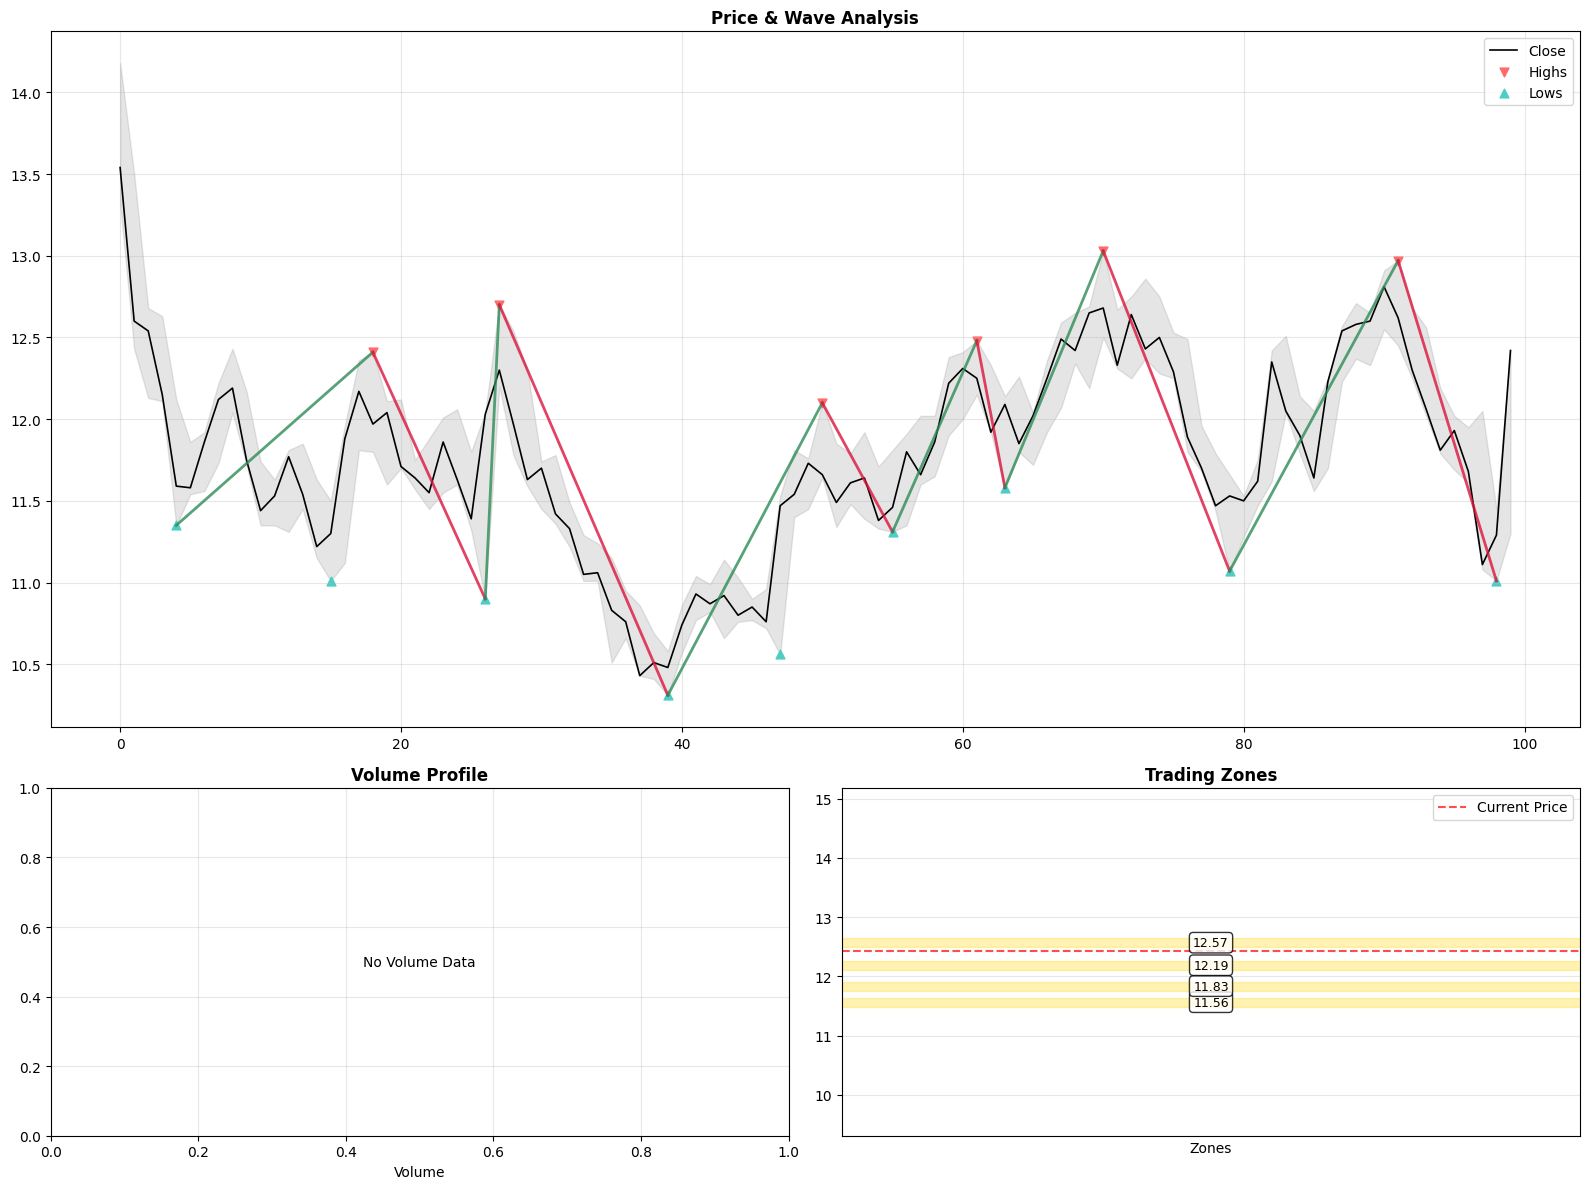

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import argrelextrema
from sklearn.cluster import KMeans
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ==================== 核心数据结构 ====================

@dataclass
class ExtremePoint:
    """极值点"""
    idx: int
    timestamp: any
    price: float
    type: str  # 'high' or 'low'
    strength: float

@dataclass  
class MarketWave:
    """市场波浪"""
    start: ExtremePoint
    end: ExtremePoint
    direction: str  # 'up' or 'down'
    length: float
    duration: int

@dataclass
class TradingZone:
    """交易区域"""
    price: float
    lower: float
    upper: float
    volume: float
    strength: float

# ==================== 核心分析引擎 ====================

class PracticalMarketAnalyzer:
    """实用市场分析器"""
    
    def __init__(self):
        self.data = None
        self.results = None
    
    def load_csv_data(self, file_path: str) -> bool:
        """加载CSV数据"""
        try:
            df = pd.read_csv(file_path, index_col='trade_date', parse_dates=['trade_date'], nrows=100)
            
            # 标准化列名
            col_map = {'open': 'open', 'high': 'high', 'low': 'low', 
                      'close': 'close', 'volume': 'volume',
                      'Open': 'open', 'High': 'high', 'Low': 'low', 
                      'Close': 'close', 'Volume': 'volume'}
            
            df.columns = [col_map.get(col, col) for col in df.columns]
            
            # 处理日期
            for date_col in ['date', 'datetime', 'time']:
                if date_col in df.columns:
                    df[date_col] = pd.to_datetime(df[date_col])
                    df.set_index(date_col, inplace=True)
                    break
            
            self.data = df
            print(f"数据加载成功: {len(df)} 行")
            return True
            
        except Exception as e:
            print(f"数据加载失败: {e}")
            return False
    
    def analyze(self) -> Dict:
        """执行分析"""
        if self.data is None:
            return {}
        
        print("开始市场分析...")
        
        # 1. 极值点检测
        extremes = self._find_extremes()
        print(f"找到 {len(extremes)} 个极值点")
        
        # 2. 波浪识别
        waves = self._identify_waves(extremes)
        print(f"识别 {len(waves)} 个波浪")
        
        # 3. 交易区域
        zones = self._find_trading_zones()
        print(f"发现 {len(zones)} 个交易区域")
        
        # 4. 成交量剖面
        volume_profile = self._build_volume_profile()
        
        # 5. 交易信号
        signals = self._generate_signals(waves, zones)
        
        self.results = {
            'extremes': extremes,
            'waves': waves,
            'zones': zones,
            'volume_profile': volume_profile,
            'signals': signals,
            'current_price': self.data['close'].iloc[-1]
        }
        
        return self.results
    
    def _find_extremes(self, window: int = 5) -> List[ExtremePoint]:
        """找极值点"""
        extremes = []
        df = self.data
        
        # 高点
        high_idx = argrelextrema(df['high'].values, np.greater, order=window)[0]
        for idx in high_idx:
            if idx < len(df):
                point = ExtremePoint(
                    idx=idx,
                    timestamp=df.index[idx],
                    price=df['high'].iloc[idx],
                    type='high',
                    strength=self._calc_strength(df, idx, 'high')
                )
                extremes.append(point)
        
        # 低点
        low_idx = argrelextrema(df['low'].values, np.less, order=window)[0]
        for idx in low_idx:
            if idx < len(df):
                point = ExtremePoint(
                    idx=idx,
                    timestamp=df.index[idx],
                    price=df['low'].iloc[idx],
                    type='low', 
                    strength=self._calc_strength(df, idx, 'low')
                )
                extremes.append(point)
        
        # 按时间排序
        extremes.sort(key=lambda x: x.idx)
        return extremes
    
    def _calc_strength(self, df: pd.DataFrame, idx: int, point_type: str) -> float:
        """计算极值点强度"""
        lookback = min(10, idx)
        lookforward = min(10, len(df) - idx - 1)
        
        if point_type == 'high':
            current = df['high'].iloc[idx]
            left = df['high'].iloc[idx-lookback:idx].max()
            right = df['high'].iloc[idx+1:idx+1+lookforward].max()
        else:
            current = df['low'].iloc[idx]
            left = df['low'].iloc[idx-lookback:idx].min()
            right = df['low'].iloc[idx+1:idx+1+lookforward].min()
        
        if left is not np.nan and right is not np.nan:
            dominance = (abs(current - left) + abs(current - right)) / (2 * abs(current))
            return min(1.0, dominance)
        
        return 0.5
    
    def _identify_waves(self, extremes: List[ExtremePoint]) -> List[MarketWave]:
        """识别波浪"""
        waves = []
        if len(extremes) < 2:
            return waves
        
        i = 0
        while i < len(extremes) - 1:
            current = extremes[i]
            
            # 找下一个相反类型的点
            j = i + 1
            while j < len(extremes) and extremes[j].type == current.type:
                j += 1
            
            if j < len(extremes):
                next_point = extremes[j]
                
                # 确定方向和长度
                if current.type == 'low' and next_point.type == 'high':
                    direction = 'up'
                    length = next_point.price - current.price
                else:
                    direction = 'down' 
                    length = current.price - next_point.price
                
                duration = next_point.idx - current.idx
                
                wave = MarketWave(
                    start=current,
                    end=next_point,
                    direction=direction,
                    length=abs(length),
                    duration=duration
                )
                waves.append(wave)
                i = j
            else:
                i += 1
        
        return waves
    
    def _find_trading_zones(self) -> List[TradingZone]:
        """找交易区域"""
        df = self.data
        
        # 基于价格聚类找区域
        prices = df['close'].values.reshape(-1, 1)
        n_clusters = min(8, len(prices) // 10)
        
        if n_clusters < 2:
            return []
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        clusters = kmeans.fit_predict(prices)
        
        zones = []
        price_range = df['high'].max() - df['low'].min()
        zone_width = price_range * 0.02
        
        for i in range(n_clusters):
            cluster_prices = df['close'].iloc[clusters == i].values
            if len(cluster_prices) > 5:  # 至少5个点
                center = np.mean(cluster_prices)
                
                # 计算区域成交量
                mask = (df['close'] >= center - zone_width) & (df['close'] <= center + zone_width)
                zone_volume = df[mask]['volume'].sum()
                
                zone = TradingZone(
                    price=center,
                    lower=center - zone_width,
                    upper=center + zone_width,
                    volume=zone_volume,
                    strength=len(cluster_prices) / len(df)
                )
                zones.append(zone)
        
        return sorted(zones, key=lambda x: x.strength, reverse=True)
    
    def _build_volume_profile(self, bins: int = 40) -> pd.DataFrame:
        """构建成交量剖面"""
        df = self.data
        
        price_min, price_max = df['low'].min(), df['high'].max()
        price_bins = np.linspace(price_min, price_max, bins)
        
        profile_data = []
        for i in range(len(price_bins) - 1):
            low, high = price_bins[i], price_bins[i+1]
            
            # 找在这个价格区间的K线
            mask = (df['low'] >= low) & (df['high'] <= high)
            volume = df[mask]['volume'].sum()
            
            profile_data.append({
                'price': (low + high) / 2,
                'low': low,
                'high': high,
                'volume': volume,
                'count': mask.sum()
            })
        
        return pd.DataFrame(profile_data)
    
    def _generate_signals(self, waves: List[MarketWave], zones: List[TradingZone]) -> List[Dict]:
        """生成交易信号"""
        signals = []
        current_price = self.data['close'].iloc[-1]
        
        # 1. 波浪反转信号
        if len(waves) >= 2:
            last_wave = waves[-1]
            if last_wave.direction == 'down' and last_wave.length > 0:
                signals.append({
                    'type': 'wave_reversal',
                    'direction': 'buy',
                    'reason': '下跌波浪结束，预期反弹',
                    'confidence': min(0.8, last_wave.length / self.data['close'].std())
                })
        
        # 2. 区域支撑信号
        for zone in zones[:3]:
            if current_price <= zone.upper and current_price >= zone.lower:
                signals.append({
                    'type': 'zone_support', 
                    'direction': 'buy',
                    'reason': f'价格进入支撑区域 {zone.price:.2f}',
                    'confidence': zone.strength
                })
                break
        
        return signals

# ==================== 简洁可视化 ====================

class CleanChartRenderer:
    """简洁图表渲染器"""
    
    def __init__(self):
        plt.style.use('default')
        self.colors = {
            'up': '#2E8B57',     # 绿色
            'down': '#DC143C',   # 红色  
            'high': '#FF6B6B',   # 亮红
            'low': '#4ECDC4',    # 青绿
            'zone': '#FFD700',   # 金色
            'volume': '#9370DB'  # 紫色
        }
    
    def render_analysis(self, data: pd.DataFrame, results: Dict) -> plt.Figure:
        """渲染分析图表"""
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1])
        
        # 主价格图
        ax1 = fig.add_subplot(gs[0, :])
        self._plot_price_chart(ax1, data, results)
        
        # 成交量剖面
        ax2 = fig.add_subplot(gs[1, 0])
        self._plot_volume_profile(ax2, results)
        
        # 交易区域
        ax3 = fig.add_subplot(gs[1, 1])  
        self._plot_trading_zones(ax3, data, results)
        
        plt.tight_layout()
        return fig
    
    def _plot_price_chart(self, ax, data: pd.DataFrame, results: Dict):
        """画价格图表"""
        # 价格线
        ax.plot(data.index, data['close'], 'k-', linewidth=1.2, label='Close')
        ax.fill_between(data.index, data['low'], data['high'], alpha=0.2, color='gray')
        
        # 极值点
        extremes = results['extremes']
        highs = [e for e in extremes if e.type == 'high']
        lows = [e for e in extremes if e.type == 'low']
        
        if highs:
            ax.scatter([e.timestamp for e in highs], [e.price for e in highs],
                      color=self.colors['high'], marker='v', s=40, label='Highs')
        
        if lows:
            ax.scatter([e.timestamp for e in lows], [e.price for e in lows],
                      color=self.colors['low'], marker='^', s=40, label='Lows')
        
        # 波浪连线 - 修复连线问题
        waves = results['waves']
        for wave in waves:
            color = self.colors['up'] if wave.direction == 'up' else self.colors['down']
            ax.plot([wave.start.timestamp, wave.end.timestamp],
                   [wave.start.price, wave.end.price],
                   color=color, linewidth=2, alpha=0.8)
        
        ax.set_title('Price & Wave Analysis', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 日期格式化
        if hasattr(data.index, 'dtype') and np.issubdtype(data.index.dtype, np.datetime64):
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    
    def _plot_volume_profile(self, ax, results: Dict):
        """画成交量剖面"""
        profile = results['volume_profile']
        
        if profile is not None and len(profile) > 0:
            # 确保有数据可显示
            valid_profile = profile[profile['volume'] > 0]
            if len(valid_profile) > 0:
                ax.barh(valid_profile['price'], valid_profile['volume'],
                       height=valid_profile['high'] - valid_profile['low'],
                       color=self.colors['volume'], alpha=0.7)
            else:
                ax.text(0.5, 0.5, 'No Volume Data', ha='center', va='center', 
                       transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, 'No Volume Data', ha='center', va='center', 
                   transform=ax.transAxes)
        
        ax.set_title('Volume Profile', fontweight='bold')
        ax.set_xlabel('Volume')
        ax.grid(True, alpha=0.3)
    
    def _plot_trading_zones(self, ax, data: pd.DataFrame, results: Dict):
        """画交易区域"""
        zones = results['zones']
        current_price = data['close'].iloc[-1]
        
        # 当前价格线
        ax.axhline(y=current_price, color='red', linestyle='--', alpha=0.7, label='Current Price')
        
        # 交易区域
        for i, zone in enumerate(zones[:4]):  # 只显示前4个
            ax.axhspan(zone.lower, zone.upper, alpha=0.3, color=self.colors['zone'])
            ax.text(0.5, zone.price, f'{zone.price:.2f}', 
                   ha='center', va='center', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_ylim(data['low'].min() - 1, data['high'].max() + 1)
        ax.set_title('Trading Zones', fontweight='bold')
        ax.set_xlabel('Zones')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xticks([])

# ==================== 文本报告 ====================

class TextReportGenerator:
    """文本报告生成器"""
    
    def generate_report(self, results: Dict) -> str:
        """生成文本报告"""
        report = []
        report.append("=" * 50)
        report.append("MARKET ANALYSIS REPORT")
        report.append("=" * 50)
        
        # 基本统计
        report.append(f"Extreme Points: {len(results['extremes'])}")
        report.append(f"Market Waves: {len(results['waves'])}") 
        report.append(f"Trading Zones: {len(results['zones'])}")
        report.append(f"Current Price: {results['current_price']:.2f}")
        report.append("")
        
        # 交易信号
        signals = results['signals']
        if signals:
            report.append("TRADING SIGNALS:")
            report.append("-" * 20)
            for i, signal in enumerate(signals, 1):
                report.append(f"{i}. {signal['type']} - {signal['direction'].upper()}")
                report.append(f"   Reason: {signal['reason']}")
                report.append(f"   Confidence: {signal['confidence']:.2f}")
                report.append("")
        else:
            report.append("No clear trading signals at this time.")
            report.append("")
        
        # 市场洞察
        report.append("MARKET INSIGHTS:")
        report.append("-" * 20)
        
        waves = results['waves']
        if waves:
            last_wave = waves[-1]
            report.append(f"Last Wave: {last_wave.direction} (length: {last_wave.length:.2f})")
            
            if len(waves) >= 2:
                prev_wave = waves[-2]
                if last_wave.length < prev_wave.length * 0.7:
                    report.append("→ Current wave is weaker (possible reversal)")
                else:
                    report.append("→ Wave strength maintained")
        
        zones = results['zones']
        if zones:
            strongest_zone = zones[0]
            current_price = results['current_price']
            if current_price <= strongest_zone.upper and current_price >= strongest_zone.lower:
                report.append(f"→ Price in key zone: {strongest_zone.price:.2f}")
            elif current_price < strongest_zone.lower:
                report.append(f"→ Below key zone: {strongest_zone.price:.2f} (support)")
            else:
                report.append(f"→ Above key zone: {strongest_zone.price:.2f} (resistance)")
        
        report.append("=" * 50)
        return "\n".join(report)

# ==================== 主接口 ====================

def analyze_market_data(csv_file: str) -> Tuple[Dict, plt.Figure]:
    """
    分析市场数据主函数
    
    Parameters:
    -----------
    csv_file : str
        CSV文件路径
        
    Returns:
    --------
    results : Dict
        分析结果
    figure : plt.Figure
        分析图表
    """
    
    # 1. 初始化分析器
    analyzer = PracticalMarketAnalyzer()
    
    # 2. 加载数据
    if not analyzer.load_csv_data(csv_file):
        raise ValueError("数据加载失败")
    
    # 3. 执行分析
    results = analyzer.analyze()
    
    # 4. 生成图表
    chart_renderer = CleanChartRenderer()
    figure = chart_renderer.render_analysis(analyzer.data, results)
    
    # 5. 生成文本报告
    report_gen = TextReportGenerator()
    report = report_gen.generate_report(results)
    print(report)
    
    return results, figure

# ==================== 使用示例 ====================

if __name__ == "__main__":
    # 使用方法 - 替换为您的CSV文件路径
    ts_code = "603979.SH"
    csv_path = fr'E:\stock\csv_version\analysis_results\{ts_code}_analysis.csv'   
    
    
    try:
        results, fig = analyze_market_data(csv_path)
        plt.show()
        
    except Exception as e:
        print(f"分析失败: {e}")